In [1]:
from pathlib import Path

import pandas as pd

In [2]:
# --- par‑box ---------------------------------------------------------------
path_box = Path("/home/loai/Documents/code/RSMLExtraction/Results/Reconstruction/measure_per_box.csv")
df_box_wid = pd.read_csv(path_box)
df_box_wid

,model,split,box,metric,time,Prediction,expertized,before_expertized
0,Segformer_bce_dice,Val,230629PN031,NumberOfPlants,1,5.000000,5.000000,5.000000
1,Segformer_bce_dice,Val,230629PN031,NumberOfOrgans,1,5.000000,5.000000,5.000000
2,Segformer_bce_dice,Val,230629PN031,TotalRootLength,1,1042.469154,1043.897956,1043.897956
3,Segformer_bce_dice,Val,230629PN031,NumberOfLateralRoots,1,0.000000,0.000000,0.000000
4,Segformer_bce_dice,Val,230629PN031,NumberOfPlants,2,5.000000,5.000000,5.000000
...,...,...,...,...,...,...,...,...
8115,Unet_cldice_dice,Test,230629PN018,NumberOfLateralRoots,28,9.000000,22.000000,7.000000
8116,Unet_cldice_dice,Test,230629PN018,NumberOfPlants,29,5.000000,4.000000,4.000000
8117,Unet_cldice_dice,Test,230629PN018,NumberOfOrgans,29,14.000000,26.000000,11.000000
8118,Unet_cldice_dice,Test,230629PN018,TotalRootLength,29,3051.771757,3061.510620,2634.655589


In [3]:
df_long = df_box_wid.melt(
    id_vars=['model', 'split', 'box', 'metric', 'time'],
    value_vars=['Prediction', 'expertized', 'before_expertized'],
    var_name='Type',
    value_name='Value'
)
df_long

,model,split,box,metric,time,Type,Value
0,Segformer_bce_dice,Val,230629PN031,NumberOfPlants,1,Prediction,5.000000
1,Segformer_bce_dice,Val,230629PN031,NumberOfOrgans,1,Prediction,5.000000
2,Segformer_bce_dice,Val,230629PN031,TotalRootLength,1,Prediction,1042.469154
3,Segformer_bce_dice,Val,230629PN031,NumberOfLateralRoots,1,Prediction,0.000000
4,Segformer_bce_dice,Val,230629PN031,NumberOfPlants,2,Prediction,5.000000
...,...,...,...,...,...,...,...
24355,Unet_cldice_dice,Test,230629PN018,NumberOfLateralRoots,28,before_expertized,7.000000
24356,Unet_cldice_dice,Test,230629PN018,NumberOfPlants,29,before_expertized,4.000000
24357,Unet_cldice_dice,Test,230629PN018,NumberOfOrgans,29,before_expertized,11.000000
24358,Unet_cldice_dice,Test,230629PN018,TotalRootLength,29,before_expertized,2634.655589


In [4]:
df_grouped = df_long.groupby(['model', 'split', 'box', 'metric', 'Type', 'time'])

# order by time
df_grouped = df_grouped.apply(lambda x: x.sort_values(by='time'))

# print the first few rows of the grouped DataFrame
df_grouped.head()

/tmp/ipykernel_100642/4189136754.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_grouped = df_grouped.apply(lambda x: x.sort_values(by='time'))


model  \
model         split box         metric               Type       time                       
Segformer_bce Test  230629PN008 NumberOfLateralRoots Prediction 1    1859  Segformer_bce   
                                                                2    1863  Segformer_bce   
                                                                3    1867  Segformer_bce   
                                                                4    1871  Segformer_bce   
                                                                5    1875  Segformer_bce   

                                                                          split  \
model         split box         metric               Type       time              
Segformer_bce Test  230629PN008 NumberOfLateralRoots Prediction 1    1859  Test   
                                                                2    1863  Test   
                                                                3    1867  Test   
                                                                4    1871  Test   
                                                                5    1875  Test   

                                                                                   box  \
model         split box         metric               Type       time                     
Segformer_bce Test  230629PN008 NumberOfLateralRoots Prediction 1    1859  230629PN008   
                                                                2    1863  230629PN008   
                                                                3    1867  230629PN008   
                                                                4    1871  230629PN008   
                                                                5    1875  230629PN008   

                                                                                         metric  \
model         split box         metric               Type       time                              
Segformer_bce Test  230629PN008 NumberOfLateralRoots Prediction 1    1859  NumberOfLateralRoots   
                                                                2    1863  NumberOfLateralRoots   
                                                                3    1867  NumberOfLateralRoots   
                                                                4    1871  NumberOfLateralRoots   
                                                                5    1875  NumberOfLateralRoots   

                                                                           time  \
model         split box         metric               Type       time              
Segformer_bce Test  230629PN008 NumberOfLateralRoots Prediction 1    1859     1   
                                                                2    1863     2   
                                                                3    1867     3   
                                                                4    1871     4   
                                                                5    1875     5   

                                                                                 Type  \
model         split box         metric               Type       time                    
Segformer_bce Test  230629PN008 NumberOfLateralRoots Prediction 1    1859  Prediction   
                                                                2    1863  Prediction   
                                                                3    1867  Prediction   
                                                                4    1871  Prediction   
                                                                5    1875  Prediction   

                                                                           Value  
model         split box         metric               Type       time              
Segformer_bce Test  230629PN008 NumberOfLateralRoots Prediction 1    1859    0.0  
                                                                2    1863   

## plots

In [5]:
# for the first model, split, box and metric. for the 3 types, plot on the same graph the evolution of the value over time

import seaborn as sns

models = df_grouped.index.get_level_values('model').unique()
splits = df_grouped.index.get_level_values('split').unique()
boxes = df_grouped.index.get_level_values('box').unique()
metrics = df_grouped.index.get_level_values('metric').unique()

print("Models disponibles :", models)
print("Splits disponibles :", splits)
print("Boxes disponibles  :", boxes)
print("Metrics disponibles:", metrics)

Models disponibles : Index(['Segformer_bce', 'Segformer_bce_dice', 'Segformer_dice', 'Unet_bce',
       'Unet_bce_dice', 'Unet_cldice_dice', 'Unet_dice'],
      dtype='object', name='model')
Splits disponibles : Index(['Test', 'Val'], dtype='object', name='split')
Boxes disponibles  : Index(['230629PN008', '230629PN010', '230629PN018', '230629PN024',
       '230629PN027', '230629PN006', '230629PN012', '230629PN014',
       '230629PN019', '230629PN031'],
      dtype='object', name='box')
Metrics disponibles: Index(['NumberOfLateralRoots', 'NumberOfOrgans', 'NumberOfPlants',
       'TotalRootLength'],
      dtype='object', name='metric')


In [6]:
print("Number of unique Models:", len(models))
print("Number of unique Splits:", len(splits))
print("Number of unique Boxes:", len(boxes))
print("Number of unique Metrics:", len(metrics))

Number of unique Models: 7
Number of unique Splits: 2
Number of unique Boxes: 10
Number of unique Metrics: 4


In [7]:
models_num = 0
splits_num = 1
boxes_num = 3
metrics_num = 3
boxes_num += splits_num * 5

selected_model = models[models_num]
selected_split = splits[splits_num]
selected_box = boxes[boxes_num]
selected_metric = metrics[metrics_num]

print(f"Modèle sélectionné  : {selected_model}")
print(f"Split sélectionné  : {selected_split}")
print(f"Boîte sélectionnée  : {selected_box}")
print(f"Métrique sélectionnée: {selected_metric}")

Modèle sélectionné  : Segformer_bce
Split sélectionné  : Val
Boîte sélectionnée  : 230629PN019
Métrique sélectionnée: TotalRootLength


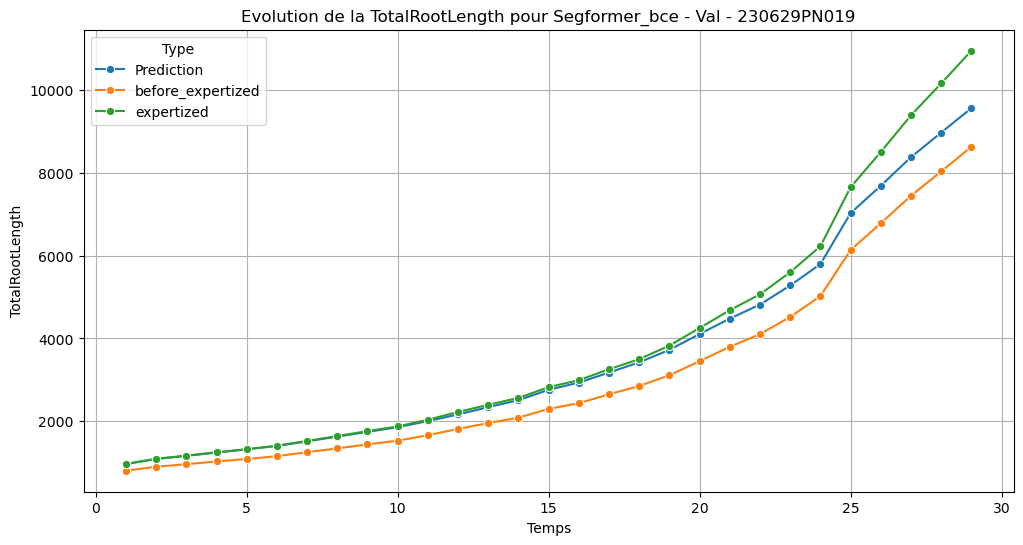

In [8]:
# plot
import matplotlib.pyplot as plt
import seaborn as sns

# Extraction
df_temp = df_grouped.xs(
    (selected_model, selected_split, selected_box, selected_metric),
    level=('model', 'split', 'box', 'metric')
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_temp,
    x='time',
    y='Value',
    hue='Type',
    marker='o'
)
plt.title(f"Evolution de la {selected_metric} pour {selected_model} - {selected_split} - {selected_box}")
plt.xlabel('Temps')
plt.ylabel(selected_metric)
plt.legend(title='Type')
plt.grid(True)
plt.show()

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

models = df_grouped.index.get_level_values('model').unique()
splits = df_grouped.index.get_level_values('split').unique()
boxes = df_grouped.index.get_level_values('box').unique()
metrics = df_grouped.index.get_level_values('metric').unique()


def plot_evolution(model_idx, split_idx, box_idx, metric_idx):
    model = models[model_idx]
    split = splits[split_idx]

    box = boxes[box_idx + split_idx * 5]
    metric = metrics[metric_idx]

    df_temp = df_grouped.xs(
        (model, split, box, metric),
        level=('model', 'split', 'box', 'metric')
    )

    plt.figure(figsize=(16, 8))
    sns.lineplot(
        data=df_temp,
        x='time', y='Value',
        hue='Type', marker='o'
    )
    plt.title(f"{metric} – {model} / {split} / {box}")
    plt.xlabel('Temps')
    plt.ylabel(metric)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


model_slider = widgets.IntSlider(min=0, max=len(models) - 1, step=1, value=0,
                                 description='Model idx')
split_slider = widgets.IntSlider(min=0, max=len(splits) - 1, step=1, value=0,
                                 description='Split idx')
box_slider = widgets.IntSlider(min=0, max=4, step=1, value=0,
                               description='Box idx')
metric_slider = widgets.IntSlider(min=0, max=len(metrics) - 1, step=1, value=0,
                                  description='Metric idx')

ui = widgets.HBox([model_slider, split_slider, box_slider, metric_slider])
out = widgets.interactive_output(
    plot_evolution,
    {'model_idx': model_slider,
     'split_idx': split_slider,
     'box_idx': box_slider,
     'metric_idx': metric_slider}
)

display(ui, out)


Output()

## Comparing stuff